In [1]:
from google.colab import files

uploaded = files.upload()

Saving employees.csv to employees.csv
Saving products.csv to products.csv
Saving sales.csv to sales.csv
Saving stores.csv to stores.csv


In [20]:
# LOAD DATASETS
# =========================================

sales_df = pd.read_csv("sales.csv")
products_df = pd.read_csv("products.csv")
stores_df = pd.read_csv("stores.csv")

print("Sales Dataset")
print(sales_df.head())

print("\nProducts Dataset")
print(products_df.head())

Sales Dataset
  sale_id   sale_date store_id product_id employee_id  quantity  \
0   SA101  2026-01-02     S101       P101        E101         2   
1   SA102  2026-01-03     S102       P102        E103         3   
2   SA103  2026-01-04     S103       P103        E105         5   
3   SA104  2026-01-05     S104       P104        E107         4   
4   SA105  2026-01-06     S105       P105        E109         6   

   discount_percent payment_mode  
0                10  Credit Card  
1                 5          UPI  
2                15         Cash  
3                 8   Debit Card  
4                12          UPI  

Products Dataset
  product_id product_name     category  price   cost     brand
0       P101       Laptop  Electronics  55000  48000      Dell
1       P102   Smartphone  Electronics  30000  25000   Samsung
2       P103   Headphones  Accessories   2000   1200      Boat
3       P104     Keyboard  Accessories   1500    900  Logitech
4       P105        Mouse  Accessories  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# CHECK MISSING VALUES
# =========================================

print("\nMissing Values")
print(sales_df.isnull().sum())



Missing Values
sale_id             0
sale_date           0
store_id            0
product_id          0
employee_id         0
quantity            0
discount_percent    0
payment_mode        0
dtype: int64


In [5]:
# DATA TYPE CHECK
# =========================================

print("\nData Types")
print(sales_df.dtypes)


Data Types
sale_id             object
sale_date           object
store_id            object
product_id          object
employee_id         object
quantity             int64
discount_percent     int64
payment_mode        object
dtype: object


In [6]:
# MERGE DATASETS
# =========================================

merged_df = pd.merge(sales_df, products_df, on="product_id")

print("\nMerged Dataset")
print(merged_df.head())


Merged Dataset
  sale_id   sale_date store_id product_id employee_id  quantity  \
0   SA101  2026-01-02     S101       P101        E101         2   
1   SA102  2026-01-03     S102       P102        E103         3   
2   SA103  2026-01-04     S103       P103        E105         5   
3   SA104  2026-01-05     S104       P104        E107         4   
4   SA105  2026-01-06     S105       P105        E109         6   

   discount_percent payment_mode product_name     category  price   cost  \
0                10  Credit Card       Laptop  Electronics  55000  48000   
1                 5          UPI   Smartphone  Electronics  30000  25000   
2                15         Cash   Headphones  Accessories   2000   1200   
3                 8   Debit Card     Keyboard  Accessories   1500    900   
4                12          UPI        Mouse  Accessories    800    400   

      brand  
0      Dell  
1   Samsung  
2      Boat  
3  Logitech  
4        HP  


In [7]:
# CALCULATE REVENUE
# =========================================

merged_df["revenue"] = (
    merged_df["quantity"] * merged_df["price"]
)

In [8]:
# CALCULATE DISCOUNT AMOUNT
# =========================================

merged_df["discount_amount"] = (
    merged_df["revenue"] *
    merged_df["discount_percent"] / 100
)

In [9]:
# FINAL REVENUE
# =========================================

merged_df["final_revenue"] = (
    merged_df["revenue"] -
    merged_df["discount_amount"]
)

In [10]:
# CALCULATE PROFIT
# =========================================

merged_df["profit"] = (
    merged_df["final_revenue"] -
    (merged_df["quantity"] * merged_df["cost"])
)

In [11]:
# PROFIT MARGIN
# =========================================

merged_df["profit_margin"] = np.where(
    merged_df["final_revenue"] > 0,
    (merged_df["profit"] / merged_df["final_revenue"]) * 100,
    0
)

In [12]:
# SUMMARY REPORT
# =========================================

summary_report = merged_df.groupby(
    "store_id"
)[["final_revenue", "profit"]].sum()

print("\nStore Summary Report")
print(summary_report)


Store Summary Report
          final_revenue   profit
store_id                        
S101           117000.0   7000.0
S102           100900.0  14900.0
S103            30820.0   5820.0
S104            67920.0   6320.0
S105            16374.0   4974.0
S106            58950.0   5950.0
S107            77600.0   6800.0
S108            36730.0   6730.0
S109            50760.0   5160.0
S110            53620.0   5820.0


In [13]:
# SAVE CLEANED DATA
# =========================================

merged_df.to_csv(
    "cleaned_sales.csv",
    index=False
)

summary_report.to_csv(
    "summary_report.csv"
)

print("\nFiles Saved Successfully")



Files Saved Successfully


In [15]:
from google.colab import files

files.download("cleaned_sales.csv")
files.download("summary_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
merged_df.head()

,sale_id,sale_date,store_id,product_id,employee_id,quantity,discount_percent,payment_mode,product_name,category,price,cost,brand,revenue,discount_amount,final_revenue,profit,profit_margin
0,SA101,2026-01-02,S101,P101,E101,2,10,Credit Card,Laptop,Electronics,55000,48000,Dell,110000,11000.0,99000.0,3000.0,3.030303
1,SA102,2026-01-03,S102,P102,E103,3,5,UPI,Smartphone,Electronics,30000,25000,Samsung,90000,4500.0,85500.0,10500.0,12.280702
2,SA103,2026-01-04,S103,P103,E105,5,15,Cash,Headphones,Accessories,2000,1200,Boat,10000,1500.0,8500.0,2500.0,29.411765
3,SA104,2026-01-05,S104,P104,E107,4,8,Debit Card,Keyboard,Accessories,1500,900,Logitech,6000,480.0,5520.0,1920.0,34.782609
4,SA105,2026-01-06,S105,P105,E109,6,12,UPI,Mouse,Accessories,800,400,HP,4800,576.0,4224.0,1824.0,43.181818


In [17]:
summary_report.head()

,final_revenue,profit
store_id,,
S101,117000.0,7000.0
S102,100900.0,14900.0
S103,30820.0,5820.0
S104,67920.0,6320.0
S105,16374.0,4974.0


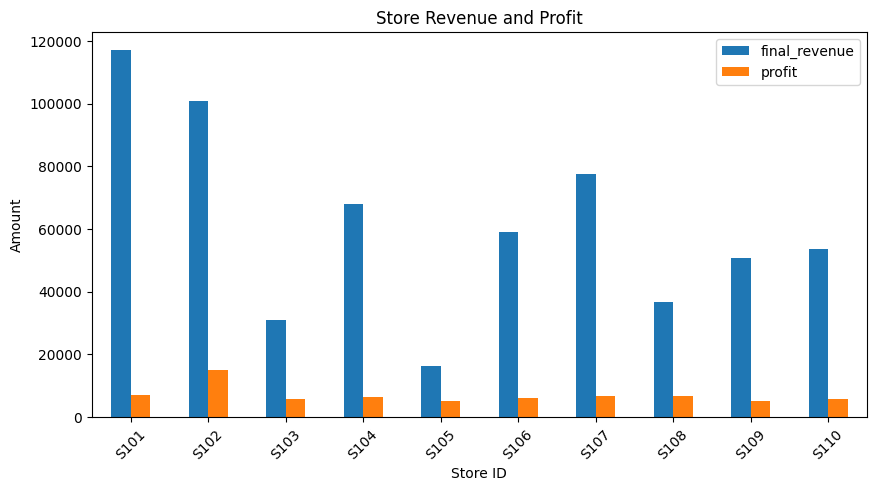

In [14]:
# VISUALIZATION
# =========================================

summary_report.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Store Revenue and Profit")
plt.xlabel("Store ID")
plt.ylabel("Amount")
plt.xticks(rotation=45)

plt.show()